# 🏆 Notebook 04 — Market Analysis & Analytical Storytelling

**Key narrative question:** *What drives success in the global video game market?*

This notebook answers eight core analytical questions and constructs a data-driven narrative about what makes a video game commercially successful.

---

### Analytical questions answered here

| # | Question | Section |
|---|---|---|
| Q1 | Top 10 best-selling games globally | [§ Q1](#q1) |
| Q2 | Platforms with highest global sales | [§ Q2](#q2) |
| Q3 | Genres that dominate global sales | [§ Q3](#q3) |
| Q4 | Publishers generating the most revenue | [§ Q4](#q4) |
| Q5–Q6 | Sales evolution over time & peak year | [§ Q5-Q6](#q5) |
| Q7 | Regional contribution to global sales | [§ Q7](#q7) |
| Q8 | Top games per region (NA, EU, JP) | [§ Q8](#q8) |
| S1 | Regional genre preferences | [§ Supporting](#s1) |
| S2 | Sales by decade | [§ Supporting](#s2) |

---

> **Pipeline context:** Raw data → Data Overview → Data Cleaning → Feature Engineering → EDA → **Analysis**

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import plotly.express as px

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print("Libraries loaded.")

Libraries loaded.


In [2]:
from src.ingestion.load_dataset import load_raw_data
from src.cleaning.clean_sales_data import clean_sales_data
from src.features.feature_engineering import engineer_features

df = engineer_features(clean_sales_data(load_raw_data()))
print(f"Working dataset: {df.shape[0]:,} games, {df.shape[1]} columns")

Working dataset: 16,598 games, 18 columns


---

## Q1 · Top 10 Best-Selling Video Games Globally <a id="q1"></a>

The best-selling titles are dominated by Nintendo franchises and Western mega-hits.
**Wii Sports** stands apart — it was bundled with the Wii console in most markets, giving it an extraordinary sales advantage.

,Rank,Name,Platform,Publisher,Genre,Global_Sales
0,1,Wii Sports,Wii,Nintendo,Sports,82.74
1,2,Super Mario Bros.,NES,Nintendo,Platform,40.24
2,3,Mario Kart Wii,Wii,Nintendo,Racing,35.82
3,4,Wii Sports Resort,Wii,Nintendo,Sports,33.00
4,5,Pokemon Red/Pokemon Blue,GB,Nintendo,Role-Playing,31.37
5,6,Tetris,GB,Nintendo,Puzzle,30.26
6,7,New Super Mario Bros.,DS,Nintendo,Platform,30.01
7,8,Wii Play,Wii,Nintendo,Misc,29.02
8,9,New Super Mario Bros. Wii,Wii,Nintendo,Platform,28.62
9,10,Duck Hunt,NES,Nintendo,Shooter,28.31


C:\Users\rendybagoez\AppData\Local\Temp\ipykernel_9132\3784639250.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x="Global_Sales", y="Name", palette="Blues_d", ax=ax)


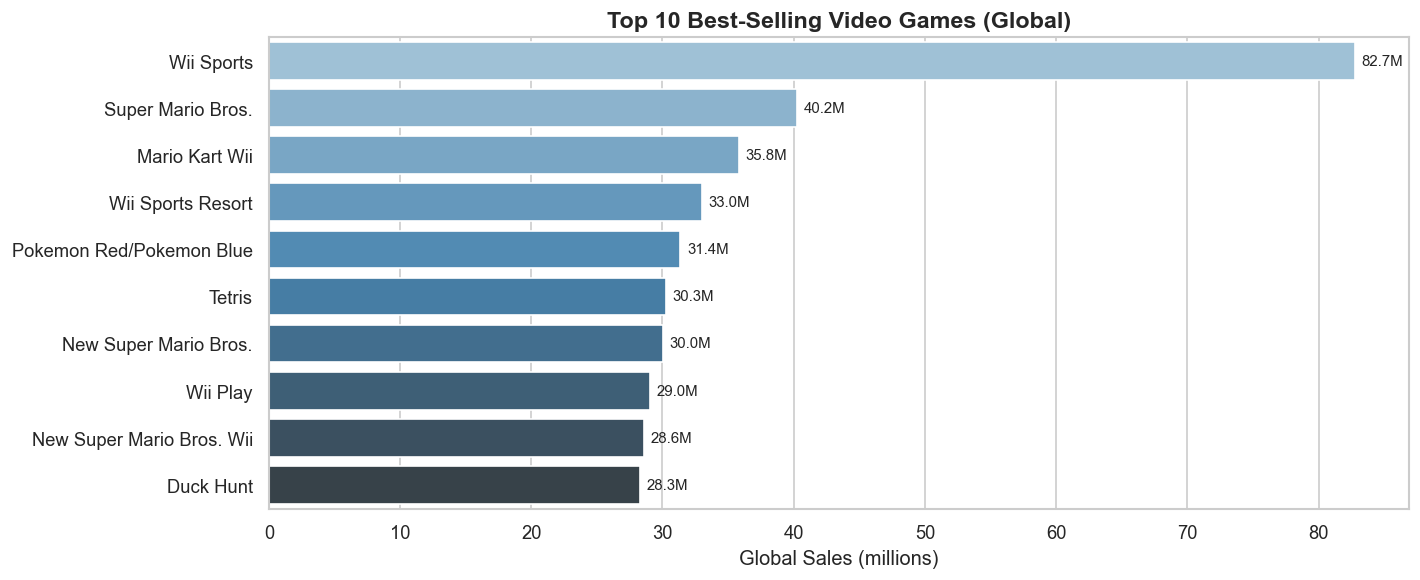

In [3]:
from src.analysis.market_analysis import top_games_global

top10 = top_games_global(df, n=10)
display(top10)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=top10, x="Global_Sales", y="Name", palette="Blues_d", ax=ax)
ax.set_title("Top 10 Best-Selling Video Games (Global)", fontsize=14, fontweight="bold")
ax.set_xlabel("Global Sales (millions)")
ax.set_ylabel("")
# Annotate sales values
for bar, val in zip(ax.patches, top10["Global_Sales"]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2, f"{val:.1f}M",
            va="center", fontsize=9)
plt.tight_layout()
plt.savefig("../reports/figures/09_top10_games.png", bbox_inches="tight")
plt.show()

---

## Q2 · Top Platforms by Global Sales <a id="q2"></a>

Platform success is a combination of hardware sales, library breadth, and market timing.
**PS2** leads all platforms — with 155M+ consoles sold and a library of 4,000+ titles, it defined an era.

,Platform,Global_Sales
0,PS2,1255.64
1,X360,979.96
2,PS3,957.84
3,Wii,926.71
4,DS,822.49
5,PS,730.66
6,GBA,318.50
7,PSP,296.28
8,PS4,278.10
9,PC,258.82


C:\Users\rendybagoez\AppData\Local\Temp\ipykernel_9132\1795386925.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plat, x="Global_Sales", y="Platform", palette="Greens_d", ax=ax)


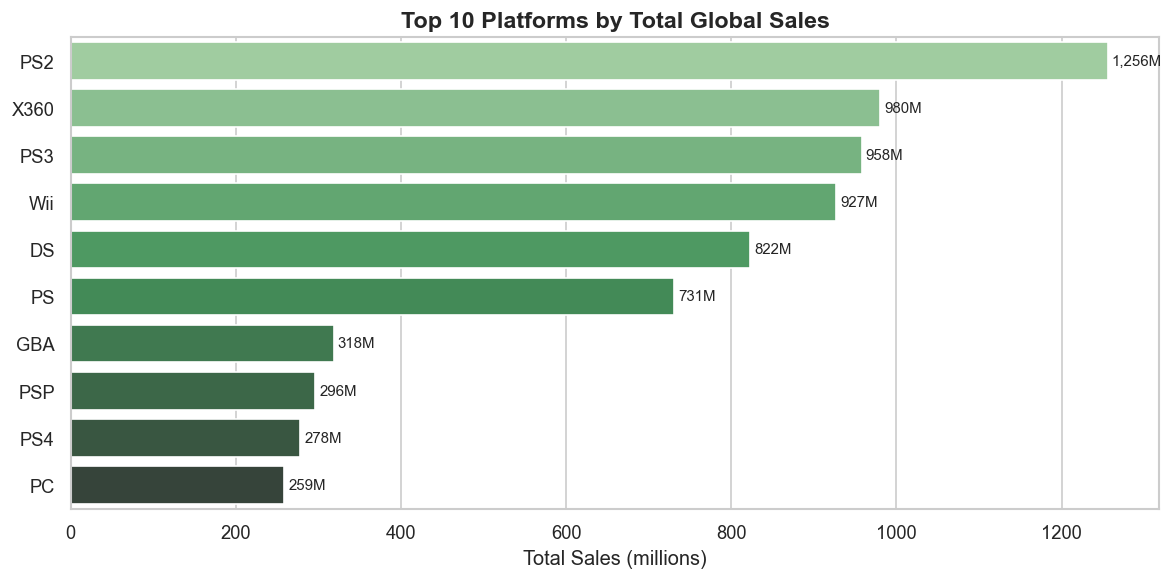

In [4]:
from src.analysis.market_analysis import top_platforms

plat = top_platforms(df, n=10)
display(plat)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=plat, x="Global_Sales", y="Platform", palette="Greens_d", ax=ax)
ax.set_title("Top 10 Platforms by Total Global Sales", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Sales (millions)")
ax.set_ylabel("")
for bar, val in zip(ax.patches, plat["Global_Sales"]):
    ax.text(val + 5, bar.get_y() + bar.get_height() / 2, f"{val:,.0f}M",
            va="center", fontsize=9)
plt.tight_layout()
plt.savefig("../reports/figures/10_top_platforms.png", bbox_inches="tight")
plt.show()

---

## Q3 · Genres That Dominate Global Sales <a id="q3"></a>

**Action** games are the most commercially dominant genre by total sales.
The top 3 — Action, Sports, and Shooter — together represent over 55% of all global sales in the dataset.

In [5]:
from src.analysis.market_analysis import top_genres

genres = top_genres(df)
display(genres)

fig = px.pie(genres, values="Global_Sales", names="Genre",
             title="Global Sales Share by Genre",
             color_discrete_sequence=px.colors.qualitative.Pastel)
fig.update_traces(textposition="inside", textinfo="percent+label")
fig.update_layout(showlegend=False)
fig.write_html("../reports/figures/11_genre_pie.html")
fig.show()

,Genre,Global_Sales
0,Action,1751.18
1,Sports,1330.93
2,Shooter,1037.37
3,Role-Playing,927.37
4,Platform,831.37
5,Misc,809.96
6,Racing,732.04
7,Fighting,448.91
8,Simulation,392.20
9,Puzzle,244.95


---

## Q4 · Publishers Generating the Most Revenue <a id="q4"></a>

The publishing landscape is highly concentrated: the top 3 publishers — **Nintendo, Electronic Arts, and Activision** — 
account for a disproportionate share of all global sales.
This reflects the power of owning iconic franchises (Mario, FIFA, Call of Duty).

,Publisher,Global_Sales
0,Nintendo,1786.56
1,Electronic Arts,1110.32
2,Activision,727.46
3,Sony Computer Entertainment,607.50
4,Ubisoft,474.72
5,Take-Two Interactive,399.54
6,THQ,340.77
7,Konami Digital Entertainment,283.64
8,Sega,272.99
9,Namco Bandai Games,254.09


C:\Users\rendybagoez\AppData\Local\Temp\ipykernel_9132\3014754812.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pubs, x="Global_Sales", y="Publisher", palette="Oranges_d", ax=ax)


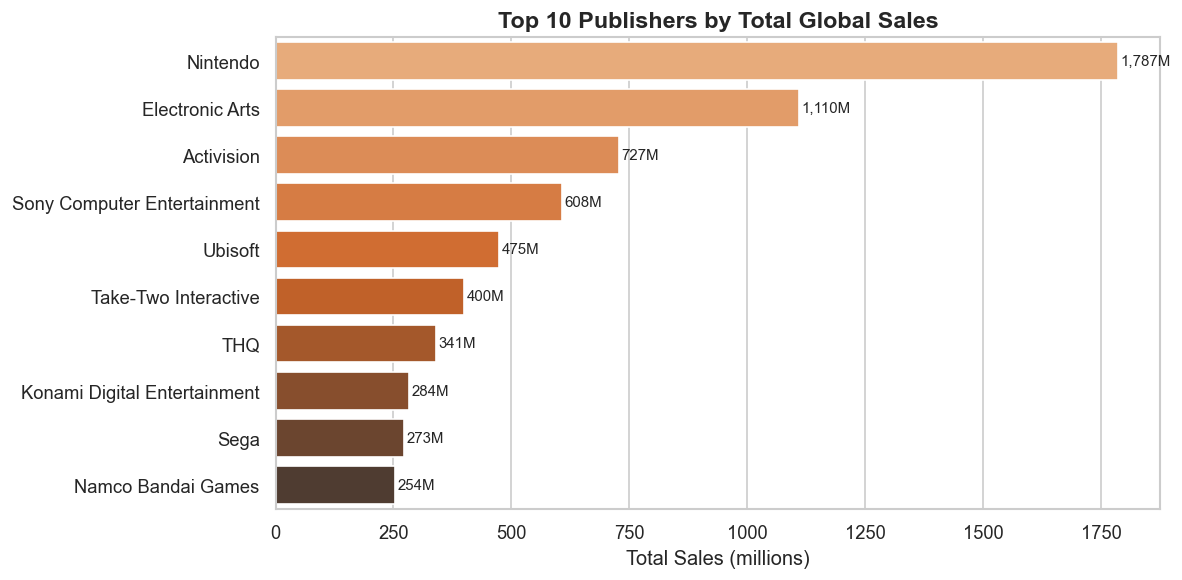

In [6]:
from src.analysis.market_analysis import top_publishers

pubs = top_publishers(df, n=10)
display(pubs)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=pubs, x="Global_Sales", y="Publisher", palette="Oranges_d", ax=ax)
ax.set_title("Top 10 Publishers by Total Global Sales", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Sales (millions)")
ax.set_ylabel("")
for bar, val in zip(ax.patches, pubs["Global_Sales"]):
    ax.text(val + 5, bar.get_y() + bar.get_height() / 2, f"{val:,.0f}M",
            va="center", fontsize=9)
plt.tight_layout()
plt.savefig("../reports/figures/12_top_publishers.png", bbox_inches="tight")
plt.show()

---

## Q5–Q6 · Sales Evolution Over Time & Peak Year <a id="q5"></a>

The global video game market (physical retail) grew rapidly through the 1990s and 2000s, 
reaching its peak around **2008–2009** — coinciding with the dominant Wii / DS / PS3 / X360 era.
The subsequent decline reflects the shift toward digital distribution and mobile gaming, which this dataset does not capture.

In [7]:
from src.analysis.market_analysis import sales_over_time, peak_sales_year

annual = sales_over_time(df)
peak = peak_sales_year(df)
print(f"📅 Peak sales year: {peak}  ({annual.loc[annual['Year'] == peak, 'Global_Sales'].values[0]:,.0f}M units)")

fig = px.line(annual, x="Year", y="Global_Sales",
              title=f"Annual Global Video Game Sales (Physical Retail) — Peak: {peak}",
              markers=True, labels={"Global_Sales": "Total Sales (millions)"})
fig.add_vline(x=peak, line_dash="dash", line_color="red",
              annotation_text=f"Peak: {peak}", annotation_position="top right")
fig.update_traces(line_color="steelblue")
fig.write_html("../reports/figures/13_annual_sales.html")
fig.show()

📅 Peak sales year: 2008  (679M units)


---

## Q7 · Regional Sales Contribution <a id="q7"></a>

North America is the single largest regional market, representing nearly half of all global sales in this dataset.
Europe is the second-largest, and Japan — while much smaller — is culturally influential and has distinct genre preferences.

In [8]:
from src.analysis.market_analysis import regional_totals

region = regional_totals(df)
region_pct = (region / region.sum() * 100).round(1)
print("Regional Sales Summary:")
display(
    pd.DataFrame({"Total Sales (M)": region.round(0).astype(int), "Share (%)": region_pct})
)

fig = px.pie(values=region.values, names=region.index,
             title="Regional Contribution to Global Video Game Sales",
             color_discrete_sequence=px.colors.qualitative.Pastel)
fig.update_traces(textposition="inside", textinfo="percent+label")
fig.write_html("../reports/figures/14_regional_share.html")
fig.show()

Regional Sales Summary:


,Total Sales (M),Share (%)
North America,4393,49.3
Europe,2434,27.3
Japan,1291,14.5
Other,798,8.9


---

## Q8 · Top Games by Region <a id="q8"></a>

Regional top sellers reveal how gaming tastes differ across markets.
**Japan** favours Nintendo-published Role-Playing games (Dragon Quest, Pokémon), while
**NA and EU** skew toward action/sports blockbusters and Western franchises (GTA, Call of Duty).

In [9]:
from src.analysis.market_analysis import top_games_by_region

region_labels = {"NA": "North America", "EU": "Europe", "JP": "Japan"}
for region_code, region_name in region_labels.items():
    print(f"\n{'─' * 50}")
    print(f"  🏅 Top 5 Games in {region_name}")
    print(f"{'─' * 50}")
    display(top_games_by_region(df, region_code, n=5))


──────────────────────────────────────────────────
  🏅 Top 5 Games in North America
──────────────────────────────────────────────────


,Name,Platform,Publisher,Genre,NA_Sales
0,Wii Sports,Wii,Nintendo,Sports,41.49
1,Super Mario Bros.,NES,Nintendo,Platform,29.08
2,Duck Hunt,NES,Nintendo,Shooter,26.93
3,Tetris,GB,Nintendo,Puzzle,23.20
4,Mario Kart Wii,Wii,Nintendo,Racing,15.85



──────────────────────────────────────────────────
  🏅 Top 5 Games in Europe
──────────────────────────────────────────────────


,Name,Platform,Publisher,Genre,EU_Sales
0,Wii Sports,Wii,Nintendo,Sports,29.02
1,Mario Kart Wii,Wii,Nintendo,Racing,12.88
2,Wii Sports Resort,Wii,Nintendo,Sports,11.01
3,Nintendogs,DS,Nintendo,Simulation,11.00
4,Grand Theft Auto V,PS3,Take-Two Interactive,Action,9.27



──────────────────────────────────────────────────
  🏅 Top 5 Games in Japan
──────────────────────────────────────────────────


,Name,Platform,Publisher,Genre,JP_Sales
0,Pokemon Red/Pokemon Blue,GB,Nintendo,Role-Playing,10.22
1,Pokemon Gold/Pokemon Silver,GB,Nintendo,Role-Playing,7.20
2,Super Mario Bros.,NES,Nintendo,Platform,6.81
3,New Super Mario Bros.,DS,Nintendo,Platform,6.50
4,Pokemon Diamond/Pokemon Pearl,DS,Nintendo,Role-Playing,6.04


---

## Supporting: Regional Genre Preferences <a id="s1"></a>

Normalising genre sales by region exposes Japan's strong RPG affinity and NA/EU's preference for Action and Sports.
This explains why publishers targeting both markets must maintain separate genre strategies.

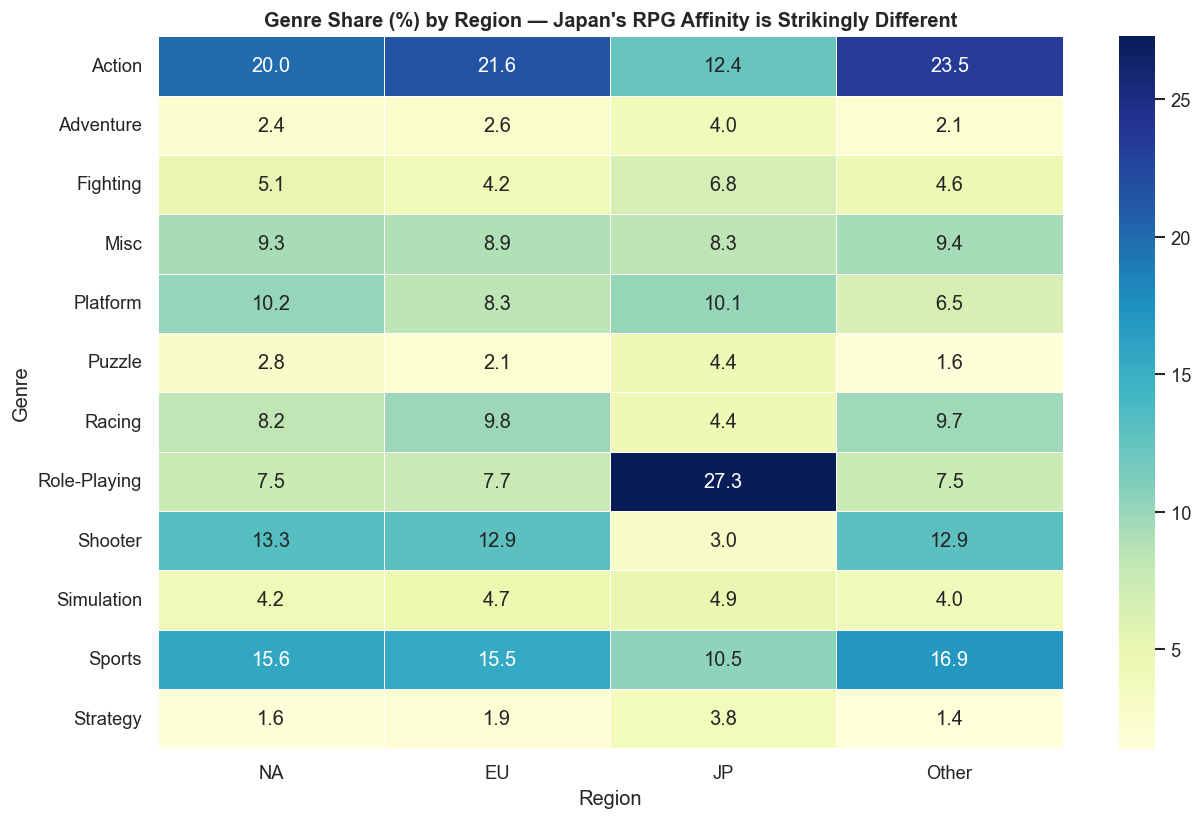

In [10]:
from src.analysis.market_analysis import genre_sales_by_region

genre_region = genre_sales_by_region(df).set_index("Genre")
genre_region.columns = ["NA", "EU", "JP", "Other"]

# Normalise to show each genre's share within a region
genre_share = genre_region.div(genre_region.sum(axis=0), axis=1) * 100

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(genre_share.round(1), annot=True, fmt=".1f", cmap="YlGnBu",
            ax=ax, linewidths=0.5, linecolor="white")
ax.set_title("Genre Share (%) by Region — Japan's RPG Affinity is Strikingly Different",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Region")
ax.set_ylabel("Genre")
plt.tight_layout()
plt.savefig("../reports/figures/15_genre_region_share.png", bbox_inches="tight")
plt.show()

---

## Supporting: Sales by Decade <a id="s2"></a>

Grouping sales by decade provides a long-range view of the industry's growth.
The **2000s** were the golden era of physical retail gaming, followed by a decline as digital distribution became dominant.

,Decade,Global_Sales
0,1980s,376.58
1,1990s,1278.91
2,2000s,4644.02
3,2010s,2520.56
4,2020s,0.29


C:\Users\rendybagoez\AppData\Local\Temp\ipykernel_9132\668688632.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=decade_data, x="Decade", y="Global_Sales", palette="viridis", ax=ax)


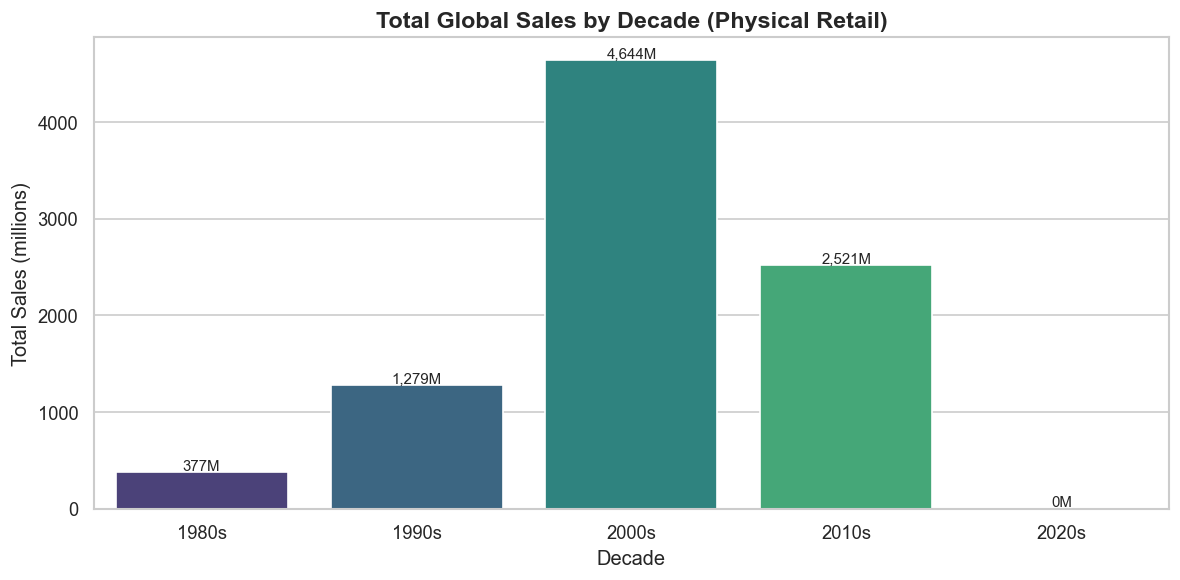

In [11]:
from src.analysis.market_analysis import sales_by_decade

decade_data = sales_by_decade(df)
display(decade_data)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=decade_data, x="Decade", y="Global_Sales", palette="viridis", ax=ax)
ax.set_title("Total Global Sales by Decade (Physical Retail)", fontsize=14, fontweight="bold")
ax.set_xlabel("Decade")
ax.set_ylabel("Total Sales (millions)")
for bar, val in zip(ax.patches, decade_data["Global_Sales"]):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 20, f"{val:,.0f}M",
            ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("../reports/figures/16_sales_by_decade.png", bbox_inches="tight")
plt.show()

---

## 🏁 What Drives Success in the Global Video Game Market?

After analysing over 16,000 titles across three decades of physical retail sales, the data points to several consistent drivers:

### 1. Platform is destiny
A small number of platforms — **PS2, Wii, X360, PS3, and DS** — account for the majority of global sales.
Launching on a high-install-base platform is the single largest predictor of commercial reach.

### 2. Genre concentration
**Action, Sports, and Shooter** titles dominate worldwide, together representing over 55% of all sales.
Publishers that consistently execute in these genres (EA, Activision) have a structural advantage.

### 3. Publisher power law
**Nintendo, Electronic Arts, and Activision** disproportionately control global revenue, driven by franchise ownership (Mario, FIFA, Call of Duty).
Owning a recurring IP means reliable year-over-year revenue without rebuilding an audience from scratch.

### 4. Regional markets are not the same
**Japan** strongly favours Role-Playing games — a preference largely absent in NA/EU.
Publishers targeting both Western and Japanese markets succeed by maintaining distinct genre strategies per region.
North America remains the dominant revenue driver at ~49% of global sales.

### 5. The market peaked around 2008–2009
Physical retail video game sales peaked during the Wii/DS/PS3/X360 era.
The decline after 2009 reflects digital distribution growth, not a shrinking gaming audience.

### 6. Blockbusters are rare — and outliers
The overwhelming majority of games sell fewer than 1 million copies.
A tiny fraction (Wii Sports, GTA V, New Super Mario Bros.) generate outsized returns.
Success in gaming follows a **power law distribution** — not a bell curve.

---

### Dataset limitations
- Covers **physical retail sales only** — digital, mobile, and PC/Steam sales are excluded.
- Data becomes sparse after 2015 as physical sales tracking declined.
- Some publisher/year fields have small amounts of missing data (handled in cleaning).

> *This analysis provides a solid foundation for understanding historical gaming market dynamics.*
> *For current market analysis, supplement with digital sales data from sources like GSD or NPD.*

---

## 👋 Closing Note — For Fellow Kaggle Explorers

Thank you for reading through this analysis! I hope the walkthrough — from raw CSV to data-driven storytelling — gave you a clear picture of how historical video game sales data can be explored systematically.

### What we covered
- **Data pipeline** — ingestion, validation, cleaning, and feature engineering, all implemented as reusable Python modules under `src/`.
- **Core questions** — top games, platforms, genres, publishers, regional breakdowns, and time-series trends.
- **Supporting insights** — regional genre preferences, decade-over-decade comparisons, and the power-law nature of blockbuster success.

### Key takeaway
> *Commercial success in the video game industry is highly concentrated — a handful of platforms, publishers, and franchises capture the lion's share of revenue. Understanding this structure is the first step toward building better predictions or business strategies.*

### Want to go further?
Here are some directions to extend this analysis:
- **Predictive modelling** — Use genre, platform, publisher, and year to predict global sales with a regression model (e.g., XGBoost or Ridge Regression).
- **Clustering** — Group games by sales profile across regions to discover hidden market segments.
- **Digital era supplement** — Combine this dataset with Steam, mobile, or GSD data to bridge the post-2015 gap.
- **Natural language features** — Use game titles and descriptions to explore sentiment or keyword patterns linked to high sales.

### Acknowledgements
- **Dataset source:** [Video Game Sales — Kaggle](https://www.kaggle.com/datasets/gregorut/videogamesales), originally scraped from [VGChartz](https://www.vgchartz.com/).
- Built with Python · pandas · matplotlib · seaborn · plotly · pandera · pytest.

---

*If you found this notebook useful, an upvote goes a long way — it helps other Kaggle users discover the work.
Feel free to fork, extend, or leave a comment with your own findings!* 🎮